# 03 — MDP GridWorld 10×10 con probabilidades, obstáculos, recompensa y descuento

Este ejercicio adapta los notebooks de **Value Iteration** y **Policy Iteration** adjuntos a un GridWorld de **10×10**.

La formulación sigue la clase:

$$MDP=(S,A,P,R,\gamma)$$

donde $S$ son estados, $A$ acciones, $P(s'|s,a)$ probabilidades de transición, $R(s)$ recompensa y $\gamma$ descuento.

La clase explica que en un GridWorld estocástico una acción puede producir el movimiento pretendido o desviarse a una dirección perpendicular; las paredes hacen que el agente permanezca en el mismo estado. fileciteturn0file0L18-L22

En este ejercicio se amplía esa idea: **cada celda tiene una probabilidad de movimiento pretendido diferente**, y los obstáculos son estados transitables con una penalización asociada a su peso/riesgo. La política óptima se obtiene mediante Bellman y **Value Iteration**. fileciteturn0file0L60-L68

## 1. Parámetros

- Grid: 10×10.
- Inicio: `(9, 0)`.
- Meta: `(0, 9)` con recompensa `+20`.
- Pozo/peligro terminal: `(4, 7)` con recompensa `-20`.
- Recompensa de vida: `-0.08`.
- $\gamma=0.92$.
- Cada celda tiene un `p_intended` diferente.
- Los obstáculos tienen un `obstacle_weight` entre 0.20 y 0.90.

El descuento sigue la definición de la clase: cada transición multiplica la recompensa futura por otra potencia de $\gamma$. fileciteturn0file0L36-L40

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 31415
rng = np.random.default_rng(SEED)

HEIGHT, WIDTH = 10, 10
START, GOAL, PIT = (9, 0), (0, 9), (4, 7)

ACTIONS = {"→": (0, 1), "↓": (1, 0), "←": (0, -1), "↑": (-1, 0)}
ACTION_NAMES = list(ACTIONS)

GAMMA = 0.92
LIVING_REWARD = -0.08
GOAL_REWARD, PIT_REWARD = 20.0, -20.0

OBSTACLES = {
    (8, 1): 0.25, (8, 4): 0.40, (7, 4): 0.55,
    (6, 4): 0.35, (6, 6): 0.70, (5, 6): 0.45,
    (4, 6): 0.60, (3, 6): 0.30, (3, 8): 0.80,
    (2, 8): 0.50, (1, 8): 0.65,
}

# Probabilidad de ejecutar la acción pretendida, diferente por celda.
p_intended = rng.uniform(0.65, 0.92, size=(HEIGHT, WIDTH))
p_intended[START] = 0.90
p_intended[GOAL] = 1.00
p_intended[PIT] = 1.00

# Recompensa por estado de llegada.
rewards = np.full((HEIGHT, WIDTH), LIVING_REWARD, dtype=float)
rewards[GOAL] = GOAL_REWARD
rewards[PIT] = PIT_REWARD

for state, weight in OBSTACLES.items():
    rewards[state] = LIVING_REWARD - 3.0 * weight

print("Grid:", HEIGHT, "x", WIDTH)
print("Inicio:", START, "Meta:", GOAL, "Pozo:", PIT)
print("Gamma:", GAMMA)
print("Obstáculos:", len(OBSTACLES))

Grid: 10 x 10
Inicio: (9, 0) Meta: (0, 9) Pozo: (4, 7)
Gamma: 0.92
Obstáculos: 11


## 2. Modelo de transición $P(s'|s,a)$

Para una acción elegida:

- con probabilidad `p_intended[s]` se ejecuta la dirección pretendida;
- el resto se reparte entre las dos direcciones perpendiculares.

Esto conserva la estructura del GridWorld de la clase, cuyo ejemplo usa ruido 0.8/0.1/0.1. fileciteturn0file0L64-L68

Aquí `p_intended` cambia de una posición a otra, por lo que **cada celda tiene una dinámica estocástica diferente**.

In [2]:
def in_grid(state):
    r, c = state
    return 0 <= r < HEIGHT and 0 <= c < WIDTH

def is_terminal(state):
    return state == GOAL or state == PIT

def transition_probs(state, action_name):
    if is_terminal(state):
        return [(state, 1.0)]

    dr, dc = ACTIONS[action_name]
    p = p_intended[state]
    perp1, perp2 = (dc, dr), (-dc, -dr)

    outcomes = [
        ((dr, dc), p),
        (perp1, (1.0 - p) / 2.0),
        (perp2, (1.0 - p) / 2.0),
    ]

    result = []
    for move, prob in outcomes:
        candidate = (state[0] + move[0], state[1] + move[1])
        if not in_grid(candidate):
            candidate = state
        result.append((candidate, prob))
    return result

def expected_next_value(state, action_name, V):
    return sum(
        prob * V[next_state]
        for next_state, prob in transition_probs(state, action_name)
    )

sample_state = (8, 2)
for action in ACTION_NAMES:
    transitions = transition_probs(sample_state, action)
    print(action, transitions, "suma =", sum(p for _, p in transitions))

→ [((8, 3), np.float64(0.8356674310791126)), ((9, 2), np.float64(0.08216628446044372)), ((7, 2), np.float64(0.08216628446044372))] suma = 1.0
↓ [((9, 2), np.float64(0.8356674310791126)), ((8, 3), np.float64(0.08216628446044372)), ((8, 1), np.float64(0.08216628446044372))] suma = 1.0
← [((8, 1), np.float64(0.8356674310791126)), ((7, 2), np.float64(0.08216628446044372)), ((9, 2), np.float64(0.08216628446044372))] suma = 1.0
↑ [((7, 2), np.float64(0.8356674310791126)), ((8, 1), np.float64(0.08216628446044372)), ((8, 3), np.float64(0.08216628446044372))] suma = 1.0


In [3]:
def value_iteration(theta=1e-7, max_iter=10000):
    # Bellman de optimalidad:
    # V(s) = R(s) + gamma * max_a sum_s' P(s'|s,a)V(s')
    V = np.zeros((HEIGHT, WIDTH), dtype=float)
    deltas = []

    for iteration in range(max_iter):
        V_new = V.copy()
        delta = 0.0

        for r in range(HEIGHT):
            for c in range(WIDTH):
                state = (r, c)

                if is_terminal(state):
                    V_new[state] = rewards[state]
                    continue

                best_q = max(
                    expected_next_value(state, action, V)
                    for action in ACTION_NAMES
                )
                V_new[state] = rewards[state] + GAMMA * best_q
                delta = max(delta, abs(V_new[state] - V[state]))

        V = V_new
        deltas.append(delta)

        if delta < theta:
            break

    return V, deltas

V_star, deltas = value_iteration()
print(f"Value Iteration: {len(deltas)} iteraciones")
print(f"Último delta: {deltas[-1]:.10f}")

Value Iteration: 56 iteraciones
Último delta: 0.0000000814


In [4]:
def extract_policy(V):
    policy = {}
    for r in range(HEIGHT):
        for c in range(WIDTH):
            state = (r, c)
            if not is_terminal(state):
                policy[state] = max(
                    ACTION_NAMES,
                    key=lambda action: expected_next_value(state, action, V)
                )
    return policy

policy_star = extract_policy(V_star)

print("Política óptima π*(s):")
for r in range(HEIGHT):
    row = []
    for c in range(WIDTH):
        s = (r, c)
        if s == START: row.append("S")
        elif s == GOAL: row.append("G")
        elif s == PIT: row.append("X")
        elif s in OBSTACLES: row.append("O")
        else: row.append(policy_star[s])
    print(" ".join(row))

Política óptima π*(s):
→ → → → → → → → → G
→ → → → → → ↑ ↑ O ↑
→ → → → → → ↑ ↑ O ↑
↑ ↑ ↑ ↑ ↑ ↑ O ↑ O ↑
↑ → ↑ ↑ ↑ ↑ O X → ↑
↑ ↑ → ↑ ↑ ↑ O ↓ → ↑
↑ → ↑ ↑ O ↑ O → → ↑
↑ ↑ ↑ ↑ O → → → ↑ ↑
↑ O ↑ ↑ O → → ↑ ↑ ↑
S → ↑ → → → → → ↑ ↑


## 3. Visualización del grid

Leyenda:

- `S`: inicio.
- `G`: meta.
- `X`: pozo terminal.
- `O`: obstáculo.
- Flechas: acción de la política óptima.
- El fondo representa $V^*(s)$.

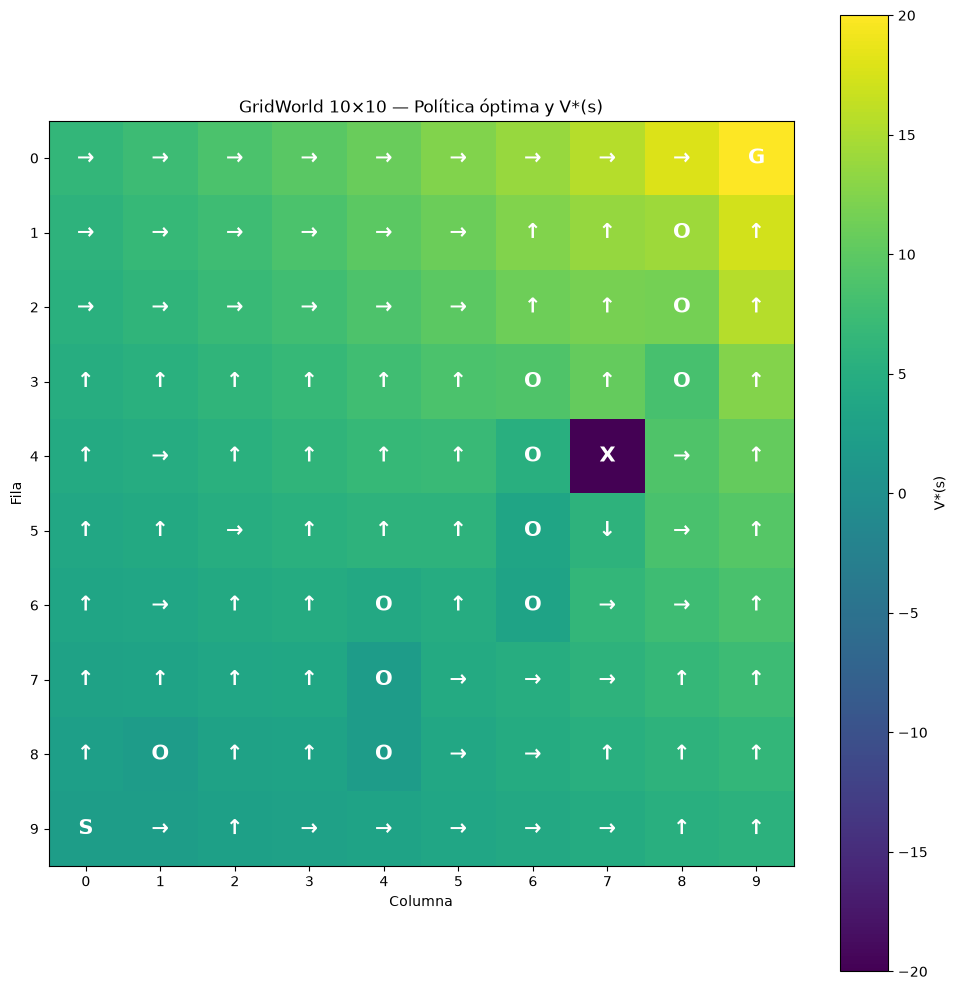

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(V_star, cmap="viridis")

for r in range(HEIGHT):
    for c in range(WIDTH):
        s = (r, c)
        if s == START: text = "S"
        elif s == GOAL: text = "G"
        elif s == PIT: text = "X"
        elif s in OBSTACLES: text = "O"
        else: text = policy_star[s]
        ax.text(c, r, text, ha="center", va="center",
                fontsize=15, fontweight="bold", color="white")

ax.set_title("GridWorld 10×10 — Política óptima y V*(s)")
ax.set_xticks(range(WIDTH)); ax.set_yticks(range(HEIGHT))
ax.set_xlabel("Columna"); ax.set_ylabel("Fila")
fig.colorbar(im, ax=ax, label="V*(s)")
plt.tight_layout()
plt.show()

## 4. Camino de máxima recompensa esperado

El camino se obtiene siguiendo la política óptima desde `START`.

Como el MDP es estocástico, la política define la **mejor acción esperada**, pero una ejecución real puede desviarse. Por eso se muestran:

1. **Camino nominal óptimo**: seguir la acción de $\pi^*$ y tomar el resultado más probable.
2. **Recorrido estocástico**: muestrear realmente $s'\sim P(\cdot|s,a)$.

La clase destaca que una misma política puede generar trayectorias distintas desde el mismo estado por la estocasticidad. fileciteturn0file0L42-L46

In [6]:
def nominal_path(max_steps=200):
    path = [START]
    current = START

    for _ in range(max_steps):
        if is_terminal(current):
            break

        action = policy_star[current]
        transitions = transition_probs(current, action)
        next_state = max(transitions, key=lambda x: x[1])[0]

        # Evita un bucle inmediato si el resultado más probable es quedarse.
        if next_state == current:
            alternatives = [x for x in transitions if x[0] != current]
            if alternatives:
                next_state = max(alternatives, key=lambda x: x[1])[0]

        path.append(next_state)
        current = next_state

    return path

nominal = nominal_path()
print("Camino nominal:")
print(" -> ".join(map(str, nominal)))
print("Pasos:", len(nominal) - 1)
print("¿Llega a la meta?:", nominal[-1] == GOAL)

Camino nominal:
(9, 0) -> (8, 0) -> (7, 0) -> (6, 0) -> (5, 0) -> (4, 0) -> (3, 0) -> (2, 0) -> (2, 1) -> (2, 2) -> (2, 3) -> (2, 4) -> (2, 5) -> (2, 6) -> (1, 6) -> (0, 6) -> (0, 7) -> (0, 8) -> (0, 9)
Pasos: 18
¿Llega a la meta?: True


In [7]:
def show_transition_table(path):
    headers = ["t", "estado", "acción", "siguiente",
               "P(siguiente)", "P(intencionada)",
               "R(siguiente)", "peso_obstáculo"]

    print(" | ".join(f"{h:>16}" for h in headers))
    print("-" * 145)

    for t in range(len(path) - 1):
        state = path[t]
        action = policy_star[state]
        next_state = path[t + 1]
        transitions = transition_probs(state, action)

        p_next = sum(p for s2, p in transitions if s2 == next_state)

        row = [
            t, state, action, next_state, p_next,
            p_intended[state], rewards[next_state],
            OBSTACLES.get(next_state, 0.0)
        ]
        print(" | ".join(f"{str(x):>16}" for x in row))

show_transition_table(nominal)

               t |           estado |           acción |        siguiente |     P(siguiente) |  P(intencionada) |     R(siguiente) |   peso_obstáculo
-------------------------------------------------------------------------------------------------------------------------------------------------
               0 |           (9, 0) |                ↑ |           (8, 0) |              0.9 |              0.9 |            -0.08 |              0.0
               1 |           (8, 0) |                ↑ |           (7, 0) | 0.8177719770659837 | 0.8177719770659837 |            -0.08 |              0.0
               2 |           (7, 0) |                ↑ |           (6, 0) | 0.8894064363340222 | 0.8894064363340222 |            -0.08 |              0.0
               3 |           (6, 0) |                ↑ |           (5, 0) | 0.7178823788691908 | 0.7178823788691908 |            -0.08 |              0.0
               4 |           (5, 0) |                ↑ |           (4, 0) | 0.89692689739932

## 5. Recompensa, descuento y retorno

La clase define el retorno descontado como:

$$G_0=\sum_{t=0}^{\infty}\gamma^tR(s_t)$$

y explica que las recompensas futuras reciben potencias crecientes de $\gamma$. fileciteturn0file0L38-L40

Para el camino calculamos:

- recompensa inmediata $R(s_t)$;
- factor de descuento $\gamma^t$;
- recompensa descontada $\gamma^tR(s_t)$;
- retorno total $G_0$.

In [8]:
def calculate_return(path):
    rows = []
    total = 0.0

    for t, state in enumerate(path):
        reward = rewards[state]
        discount = GAMMA ** t
        discounted_reward = discount * reward
        total += discounted_reward
        rows.append((t, state, reward, discount, discounted_reward, total))

    return rows, total

return_rows, total_return = calculate_return(nominal)

print(f"{'t':>3} {'estado':>12} {'R':>10} {'gamma^t':>12} "
      f"{'R descontada':>16} {'retorno acumulado':>20}")
print("-" * 80)

for t, state, reward, discount, disc_reward, acc in return_rows:
    print(f"{t:>3} {str(state):>12} {reward:>10.3f} "
          f"{discount:>12.6f} {disc_reward:>16.6f} {acc:>20.6f}")

print("\nRETORNO DESCONTADO TOTAL G0 =", round(total_return, 6))

  t       estado          R      gamma^t     R descontada    retorno acumulado
--------------------------------------------------------------------------------
  0       (9, 0)     -0.080     1.000000        -0.080000            -0.080000
  1       (8, 0)     -0.080     0.920000        -0.073600            -0.153600
  2       (7, 0)     -0.080     0.846400        -0.067712            -0.221312
  3       (6, 0)     -0.080     0.778688        -0.062295            -0.283607
  4       (5, 0)     -0.080     0.716393        -0.057311            -0.340918
  5       (4, 0)     -0.080     0.659082        -0.052727            -0.393645
  6       (3, 0)     -0.080     0.606355        -0.048508            -0.442153
  7       (2, 0)     -0.080     0.557847        -0.044628            -0.486781
  8       (2, 1)     -0.080     0.513219        -0.041058            -0.527839
  9       (2, 2)     -0.080     0.472161        -0.037773            -0.565612
 10       (2, 3)     -0.080     0.434388        -0

## 6. Obstáculos y sus pesos

Los obstáculos son **celdas peligrosas transitables**, no paredes.

El peso $w$ produce una penalización:

$$R(s_{obstáculo})=-0.08-3w$$

Así, un obstáculo con `w=0.80` es más costoso que uno con `w=0.25`.

Además, `p_intended` representa la incertidumbre del movimiento. Por tanto:

- **probabilidad de movimiento** → incertidumbre de la acción;
- **peso del obstáculo** → severidad del riesgo al entrar en la celda.

In [9]:
print(f"{'Obstáculo':>12} {'Peso':>10} {'Recompensa':>14} {'P(intencionada)':>18}")
print("-" * 60)

for state, weight in OBSTACLES.items():
    print(f"{str(state):>12} {weight:>10.2f} "
          f"{rewards[state]:>14.3f} {p_intended[state]:>18.3f}")

   Obstáculo       Peso     Recompensa    P(intencionada)
------------------------------------------------------------
      (8, 1)       0.25         -0.830              0.651
      (8, 4)       0.40         -1.280              0.715
      (7, 4)       0.55         -1.730              0.715
      (6, 4)       0.35         -1.130              0.915
      (6, 6)       0.70         -2.180              0.683
      (5, 6)       0.45         -1.430              0.655
      (4, 6)       0.60         -1.880              0.917
      (3, 6)       0.30         -0.980              0.741
      (3, 8)       0.80         -2.480              0.667
      (2, 8)       0.50         -1.580              0.728
      (1, 8)       0.65         -2.030              0.908


## 7. Recorrido estocástico reproducible

Ejecutamos la política óptima como agente real:

$$s_{t+1}\sim P(\cdot|s_t,\pi^*(s_t))$$

El `seed` hace reproducible el resultado. Es normal que este recorrido sea distinto del camino nominal.

In [10]:
def stochastic_rollout(seed=2026, max_steps=100):
    local_rng = np.random.default_rng(seed)
    path = [START]
    actions_taken = []
    current = START

    for _ in range(max_steps):
        if is_terminal(current):
            break

        action = policy_star[current]
        transitions = transition_probs(current, action)

        states = [s for s, _ in transitions]
        probs = np.array([p for _, p in transitions], dtype=float)
        probs /= probs.sum()

        index = local_rng.choice(len(states), p=probs)
        next_state = states[index]

        actions_taken.append(action)
        path.append(next_state)
        current = next_state

    return path, actions_taken

rollout_path, rollout_actions = stochastic_rollout()

print("Recorrido estocástico:")
for i, state in enumerate(rollout_path):
    if i < len(rollout_actions):
        print(f"t={i:02d} {state} --{rollout_actions[i]}--> ", end="")
    else:
        print(f"t={i:02d} {state}")

_, rollout_return = calculate_return(rollout_path)
print("\nRetorno descontado =", round(rollout_return, 6))
print("Llegó a la meta:", rollout_path[-1] == GOAL)
print("Terminó en:", rollout_path[-1])

Recorrido estocástico:
t=00 (9, 0) --↑--> t=01 (8, 0) --↑--> t=02 (7, 0) --↑--> t=03 (6, 0) --↑--> t=04 (5, 0) --↑--> t=05 (4, 0) --↑--> t=06 (4, 0) --↑--> t=07 (4, 1) --→--> t=08 (4, 2) --↑--> t=09 (3, 2) --↑--> t=10 (2, 2) --→--> t=11 (1, 2) --→--> t=12 (0, 2) --→--> t=13 (0, 3) --→--> t=14 (0, 4) --→--> t=15 (0, 5) --→--> t=16 (0, 6) --→--> t=17 (0, 7) --→--> t=18 (0, 8) --→--> t=19 (0, 9)

Retorno descontado = 3.30713
Llegó a la meta: True
Terminó en: (0, 9)


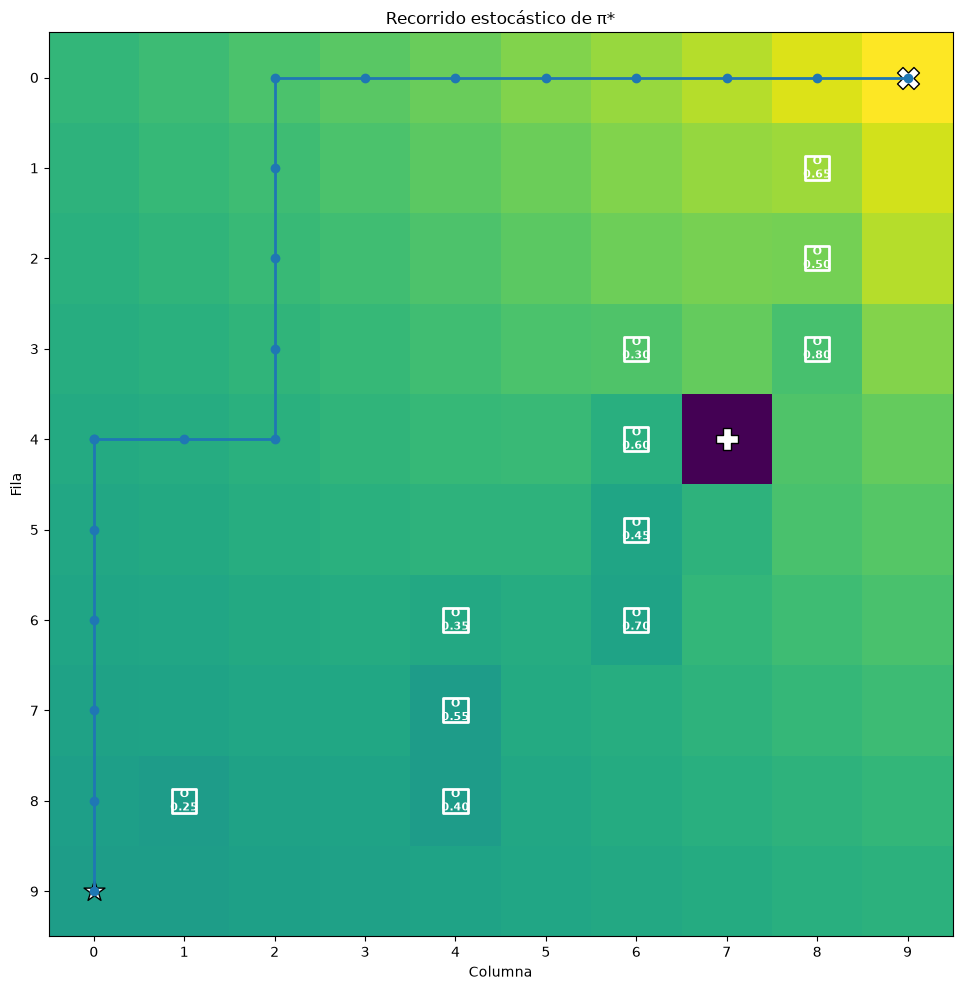

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(V_star, cmap="viridis")

for state, weight in OBSTACLES.items():
    r, c = state
    ax.scatter(c, r, s=300, marker="s", facecolors="none",
               edgecolors="white", linewidths=2)
    ax.text(c, r, f"O\n{weight:.2f}", ha="center", va="center",
            fontsize=8, color="white", fontweight="bold")

rr = [s[0] for s in rollout_path]
cc = [s[1] for s in rollout_path]
ax.plot(cc, rr, marker="o", linewidth=2)

ax.scatter(START[1], START[0], s=250, marker="*", color="white", edgecolors="black")
ax.scatter(GOAL[1], GOAL[0], s=250, marker="X", color="white", edgecolors="black")
ax.scatter(PIT[1], PIT[0], s=250, marker="P", color="white", edgecolors="black")

ax.set_title("Recorrido estocástico de π*")
ax.set_xticks(range(WIDTH)); ax.set_yticks(range(HEIGHT))
ax.set_xlabel("Columna"); ax.set_ylabel("Fila")
plt.tight_layout()
plt.show()

## 8. Interpretación

El notebook implementa el flujo de los archivos adjuntos:

1. Construir el MDP $(S,A,P,R,\gamma)$.
2. Definir transiciones estocásticas.
3. Aplicar **Value Iteration** mediante Bellman de optimalidad.
4. Extraer la política óptima $\pi^*$.
5. Seguir la política desde el estado inicial.
6. Calcular recompensa y descuento.
7. Mostrar pesos de obstáculos.
8. Comparar el camino nominal con una ejecución estocástica.

La clase señala que la política óptima se extrae escogiendo la acción que maximiza la utilidad esperada del siguiente estado. fileciteturn0file0L56-L60

**Nota:** los obstáculos se modelan como celdas peligrosas transitables para poder mostrar explícitamente sus pesos. Esto es distinto de una pared: una pared impediría el movimiento y dejaría al agente en el estado actual. fileciteturn0file0L18-L22

Para ejecutar el notebook con Python 3.14.5 se requieren `numpy` y `matplotlib`.

## 9. Preguntas

1. Qué pasa si todos los obstáculos tienen el mismo peso? todos tendrían la misma penalización, por lo que se pierde la diferenciación entre niveles de riesgo, aunque el algoritmo todavía puede elegir rutas distintas por su ubicación y las probabilidades de transición
2. Qué ocurre si no incluyo factor/función de descuento o penalización? si $\gamma=1$ y no existen costos por paso, las recompensas futuras tienen el mismo valor independientemente de la distancia, por lo que pueden aparecer caminos inecesariamente largos con la misma recompensa
3. Cómo debo asignar valores para cada posición $(i,j)$ de tal manera que no sea aleatoria? se pueden asignar mediante una regla deterministica según la posición $(i,j)$, por ejemplo usando la distancia a la meta o a los obstaculos
4. Qué ocurre con caminos de igual recompensa? cuando dos acciones producen el mismo valor esperado, existen varias acciones o caminos optimos. El algoritmo tiene que definir un criterio de desempate, como elegir el camino mas corto, o conservar todas las acciones que tienen el mismo valor optimo